In [103]:
from google.colab import drive
drive.mount("/content/drive")

import os
os.chdir('/content/drive/MyDrive/Stock')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [104]:
# !wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
# !tar -xzvf ta-lib-0.4.0-src.tar.gz
# %cd ta-lib
# !./configure --prefix=/usr
# !make
# !make install
# !pip install Ta-Lib

In [105]:
! pip install TA-Lib

In [106]:
import talib
print(talib.__version__)

0.7.1


In [107]:
import pandas as pd

# 使用 FinMind.ipynb 所抓取的基本面資料
df = pd.read_csv("2330.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df = df[df["date"] != "2025-07-30"].reset_index(drop=True)
df

,date,stock_id,Trading_Volume,Trading_money,open,max,min,close,spread,Trading_turnover
0,2023-05-02,2330,17142380,8572554842,500.0,502.0,496.5,501.0,-1.0,18247
1,2023-05-03,2330,12694698,6305914905,496.0,498.0,495.0,496.0,-5.0,25658
2,2023-05-04,2330,13699933,6818128036,497.0,499.5,496.0,498.0,2.0,14801
3,2023-05-05,2330,7898012,3949232374,500.0,502.0,498.5,500.0,2.0,10944
4,2023-05-08,2330,11737287,5932968954,509.0,509.0,502.0,504.0,4.0,13709
...,...,...,...,...,...,...,...,...,...,...
764,2026-06-25,2330,41099957,98673938497,2410.0,2420.0,2390.0,2390.0,0.0,132387
765,2026-06-26,2330,53800344,126177715258,2360.0,2370.0,2325.0,2340.0,-50.0,464927
766,2026-06-29,2330,38133782,90337385683,2330.0,2395.0,2330.0,2370.0,30.0,93276
767,2026-06-30,2330,49540227,120516271220,2440.0,2475.0,2410.0,2410.0,40.0,104582


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              769 non-null    datetime64[ns]
 1   stock_id          769 non-null    int64         
 2   Trading_Volume    769 non-null    int64         
 3   Trading_money     769 non-null    int64         
 4   open              769 non-null    float64       
 5   max               769 non-null    float64       
 6   min               769 non-null    float64       
 7   close             769 non-null    float64       
 8   spread            769 non-null    float64       
 9   Trading_turnover  769 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(4)
memory usage: 60.2 KB


# 移動平均 MA（Moving Average）

常見的移動平均有三種：簡單移動平均（SMA）、加權移動平均（WMA）、指數移動平均（EMA），這邊只示範簡單移動平均（SMA）

In [109]:
df["SMA5"] = talib.SMA(df["close"], timeperiod=5)
df["SMA10"] = talib.SMA(df["close"], timeperiod=10)
df["SMA20"] = talib.SMA(df["close"], timeperiod=20)
# df["SMA60"] = talib.SMA(df["close"], timeperiod=60)

# df.dropna(inplace=True)
df.head()

,date,stock_id,Trading_Volume,Trading_money,open,max,min,close,spread,Trading_turnover,SMA5,SMA10,SMA20
0,2023-05-02,2330,17142380,8572554842,500.0,502.0,496.5,501.0,-1.0,18247,NaN,NaN,NaN
1,2023-05-03,2330,12694698,6305914905,496.0,498.0,495.0,496.0,-5.0,25658,NaN,NaN,NaN
2,2023-05-04,2330,13699933,6818128036,497.0,499.5,496.0,498.0,2.0,14801,NaN,NaN,NaN
3,2023-05-05,2330,7898012,3949232374,500.0,502.0,498.5,500.0,2.0,10944,NaN,NaN,NaN
4,2023-05-08,2330,11737287,5932968954,509.0,509.0,502.0,504.0,4.0,13709,499.8,NaN,NaN


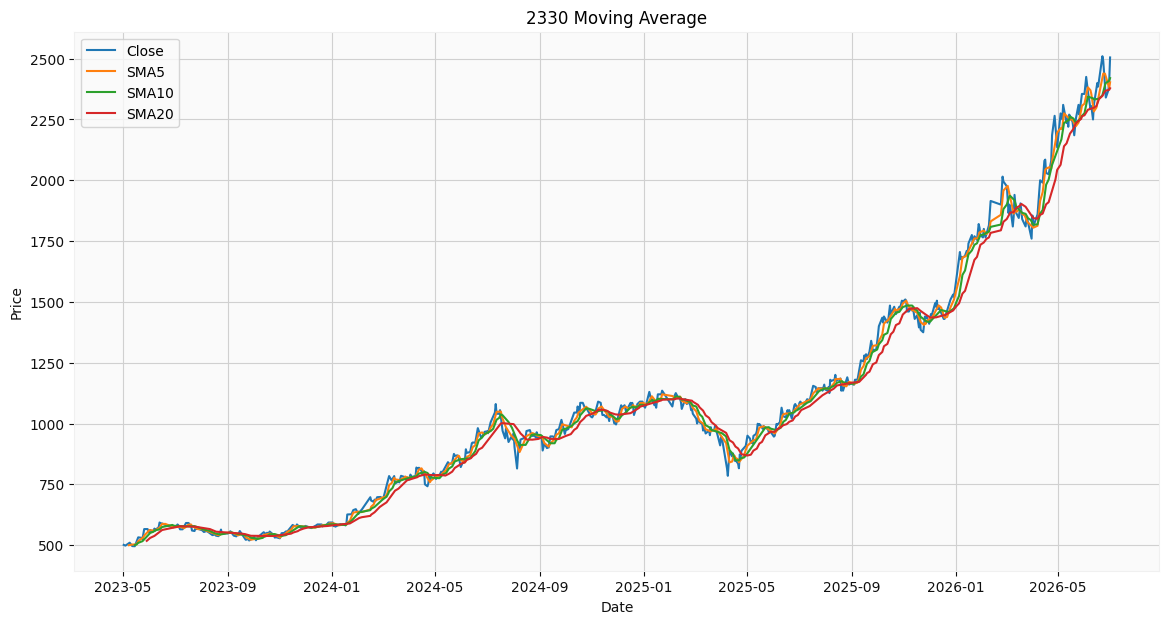

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(df["date"], df["close"], label="Close")
plt.plot(df["date"], df["SMA5"], label="SMA5")
plt.plot(df["date"], df["SMA10"], label="SMA10")
plt.plot(df["date"], df["SMA20"], label="SMA20")

plt.title("2330 Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [111]:
! pip install mplfinance

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


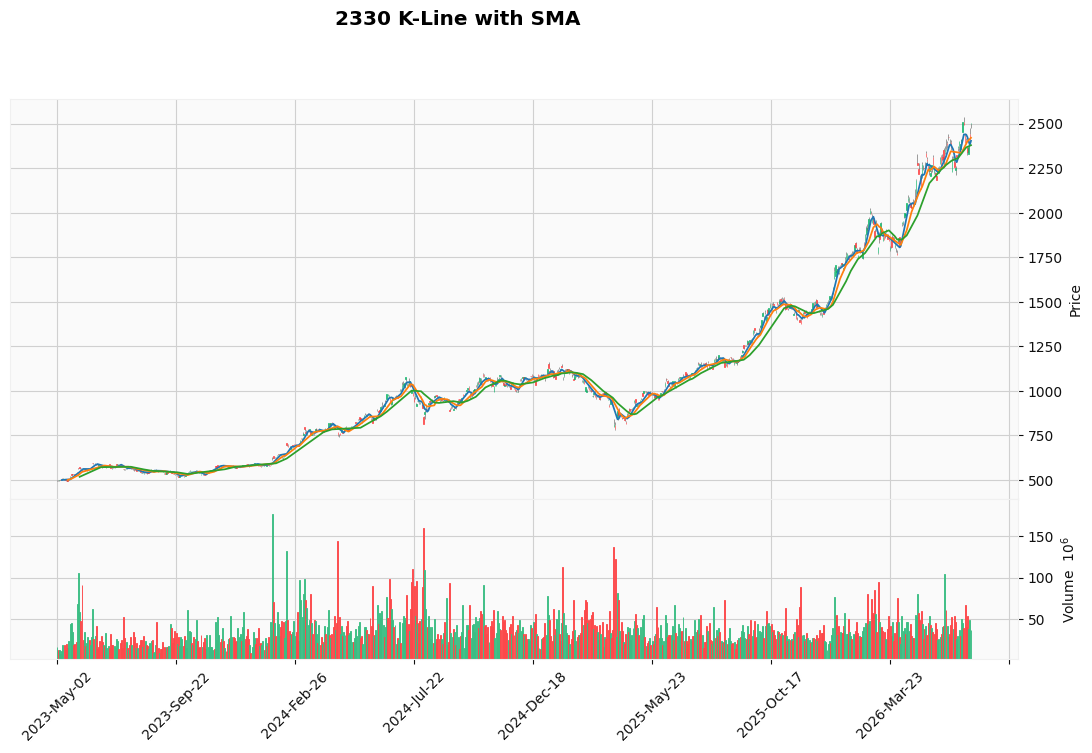

In [112]:
import mplfinance as mpf

df["date"] = pd.to_datetime(df["date"])

# mplfinance 需使用OHLCV
plot_df = df.copy()
plot_df = plot_df.rename(columns={
    "open": "Open",
    "max": "High",
    "min": "Low",
    "close": "Close",
    "Trading_Volume": "Volume"})

plot_df = plot_df.set_index("date")

# 畫 K 線 + 均線(使用已經算好的 SMA5、SMA10、SMA20)
apds = [
    mpf.make_addplot(plot_df["SMA5"]),
    mpf.make_addplot(plot_df["SMA10"]),
    mpf.make_addplot(plot_df["SMA20"]),]

mpf.plot(
    plot_df,
    type="candle",
    addplot=apds,
    volume=True,
    style="yahoo",
    figsize=(14, 8),
    title="2330 K-Line with SMA")

# 隨機指標 KD（Stochastic Oscillator）

優點
*   操作簡單，容易上手
*   反應靈敏，擅長震盪盤操作
*   可與多種指標搭配使用

缺點
*   易產生假訊號，特別是在趨勢行情中
*   過於靈敏，可能導致過度交易
*   依賴技術參數設定

可搭配 RSI 指標：強化超買超賣訊號、MACD 指標：濾除雜訊、確認中長期動能、移動平均線（MA）：確認趨勢方向


In [113]:
df["K"], df["D"] = talib.STOCH(
    high=df["max"],
    low=df["min"],
    close=df["close"],
    fastk_period=9,
    slowk_period=3,
    slowk_matype=0,   # 0 = SMA
    slowd_period=3,
    slowd_matype=0    # 0 = SMA
)

df[["date", "close", "K", "D"]].tail()

,date,close,K,D
764,2026-06-25,2390.0,60.784929,78.623119
765,2026-06-26,2340.0,34.447933,58.581894
766,2026-06-29,2370.0,23.129252,39.454038
767,2026-06-30,2410.0,23.015873,26.864353
768,2026-07-01,2505.0,49.206349,31.783825


# 相對強弱指數 RSI（Relative Strength Index）



可搭配 移動平均線：確認整體方向不變、MACD：增加交易信號、布林通道：把握區間震盪行情中的短線機會

In [114]:
df["RSI_7"] = talib.RSI(df["close"], timeperiod=7)
df["RSI_14"] = talib.RSI(df["close"], timeperiod=14)

df[["date", "close", "RSI_7", "RSI_14"]].tail()

,date,close,RSI_7,RSI_14
764,2026-06-25,2390.0,50.495949,55.109435
765,2026-06-26,2340.0,41.979003,50.162778
766,2026-06-29,2370.0,48.105935,52.894838
767,2026-06-30,2410.0,55.427595,56.332170
768,2026-07-01,2505.0,67.955028,63.200394


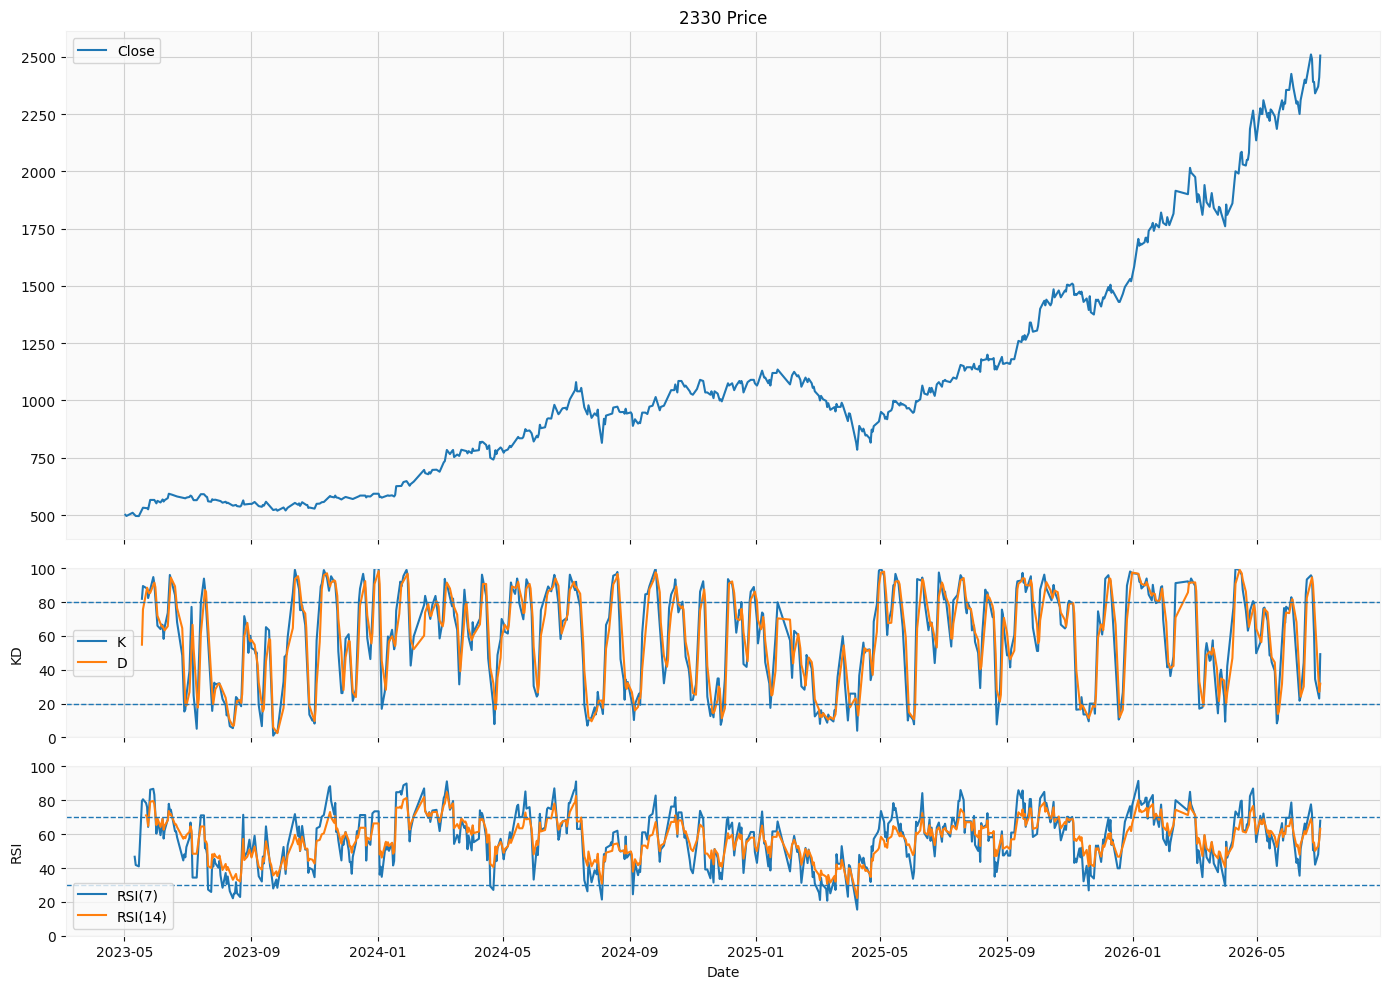

In [115]:
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1, 1]}
)

# 股價
ax1.plot(df["date"], df["close"], label="Close")
ax1.set_title("2330 Price")
ax1.legend()
ax1.grid(True)

# KD
ax2.plot(df["date"], df["K"], label="K")
ax2.plot(df["date"], df["D"], label="D")
ax2.axhline(80, linestyle="--", linewidth=1)
ax2.axhline(20, linestyle="--", linewidth=1)
ax2.set_ylim(0, 100)
ax2.set_ylabel("KD")
ax2.legend()
ax2.grid(True)

# RSI
ax3.plot(df["date"], df["RSI_7"], label="RSI(7)")
ax3.plot(df["date"], df["RSI_14"], label="RSI(14)")
ax3.axhline(70, linestyle="--", linewidth=1)
ax3.axhline(30, linestyle="--", linewidth=1)
ax3.set_ylim(0, 100)
ax3.set_ylabel("RSI")
ax3.set_xlabel("Date")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

# 布林通道 BB（Bollinger Bands）

In [116]:
df["BB_Upper"], df["BB_Middle"], df["BB_Lower"] = talib.BBANDS(
    df["close"],
    timeperiod=20,
    nbdevup=2,     # 2 倍標準差
    nbdevdn=2,
    matype=0)      # 0 = SMA

df[["date", "close", "BB_Upper", "BB_Middle", "BB_Lower"]].tail()

,date,close,BB_Upper,BB_Middle,BB_Lower
764,2026-06-25,2390.0,2498.759434,2366.25,2233.740566
765,2026-06-26,2340.0,2497.577496,2368.50,2239.422504
766,2026-06-29,2370.0,2498.179244,2369.25,2240.320756
767,2026-06-30,2410.0,2501.938447,2372.00,2242.061553
768,2026-07-01,2505.0,2520.562157,2378.25,2235.937843


/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


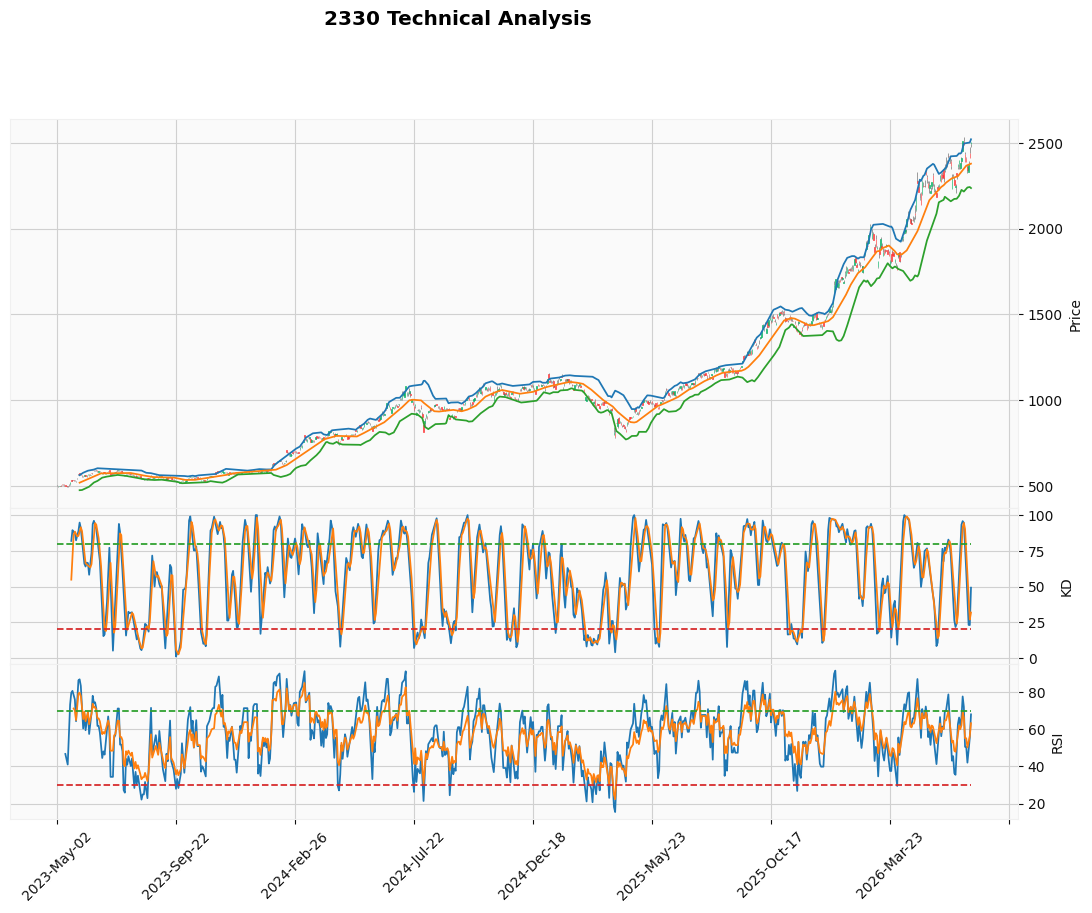

In [117]:
# mplfinance 需使用OHLCV
plot_df = df.rename(columns={
    "open": "Open",
    "max": "High",
    "min": "Low",
    "close": "Close",
    "Trading_Volume": "Volume"
}).set_index("date")

# KD
kd80 = mpf.make_addplot([80]*len(plot_df), panel=1, linestyle='--')
kd20 = mpf.make_addplot([20]*len(plot_df), panel=1, linestyle='--')

# RSI
rsi70 = mpf.make_addplot([70]*len(plot_df), panel=2, linestyle='--')
rsi30 = mpf.make_addplot([30]*len(plot_df), panel=2, linestyle='--')

apds = [
    # 布林通道
    mpf.make_addplot(plot_df["BB_Upper"], panel=0),
    mpf.make_addplot(plot_df["BB_Middle"], panel=0),
    mpf.make_addplot(plot_df["BB_Lower"], panel=0),

    # KD
    mpf.make_addplot(plot_df["K"], panel=1, ylabel="KD"),
    mpf.make_addplot(plot_df["D"], panel=1),

    # RSI
    mpf.make_addplot(plot_df["RSI_7"], panel=2, ylabel="RSI"),
    mpf.make_addplot(plot_df["RSI_14"], panel=2, ylabel="RSI"),

    # 超買超賣
    kd80, kd20,
    rsi70, rsi30]

mpf.plot(
    plot_df,
    type="candle",
    addplot=apds,
    volume=False,              # 不顯示成交量
    style="yahoo",
    figsize=(14, 10),
    panel_ratios=(5, 2, 2),
    title="2330 Technical Analysis")

# MACD（Moving Average Convergence / Divergence）

In [118]:
df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = talib.MACD(
    df["close"],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9)

df[["date", "close", "MACD", "MACD_Signal", "MACD_Hist"]].tail()

,date,close,MACD,MACD_Signal,MACD_Hist
764,2026-06-25,2390.0,49.297694,48.539593,0.758101
765,2026-06-26,2340.0,41.568421,47.145358,-5.576938
766,2026-06-29,2370.0,37.432171,45.202721,-7.770550
767,2026-06-30,2410.0,36.955825,43.553342,-6.597517
768,2026-07-01,2505.0,43.739818,43.590637,0.149181


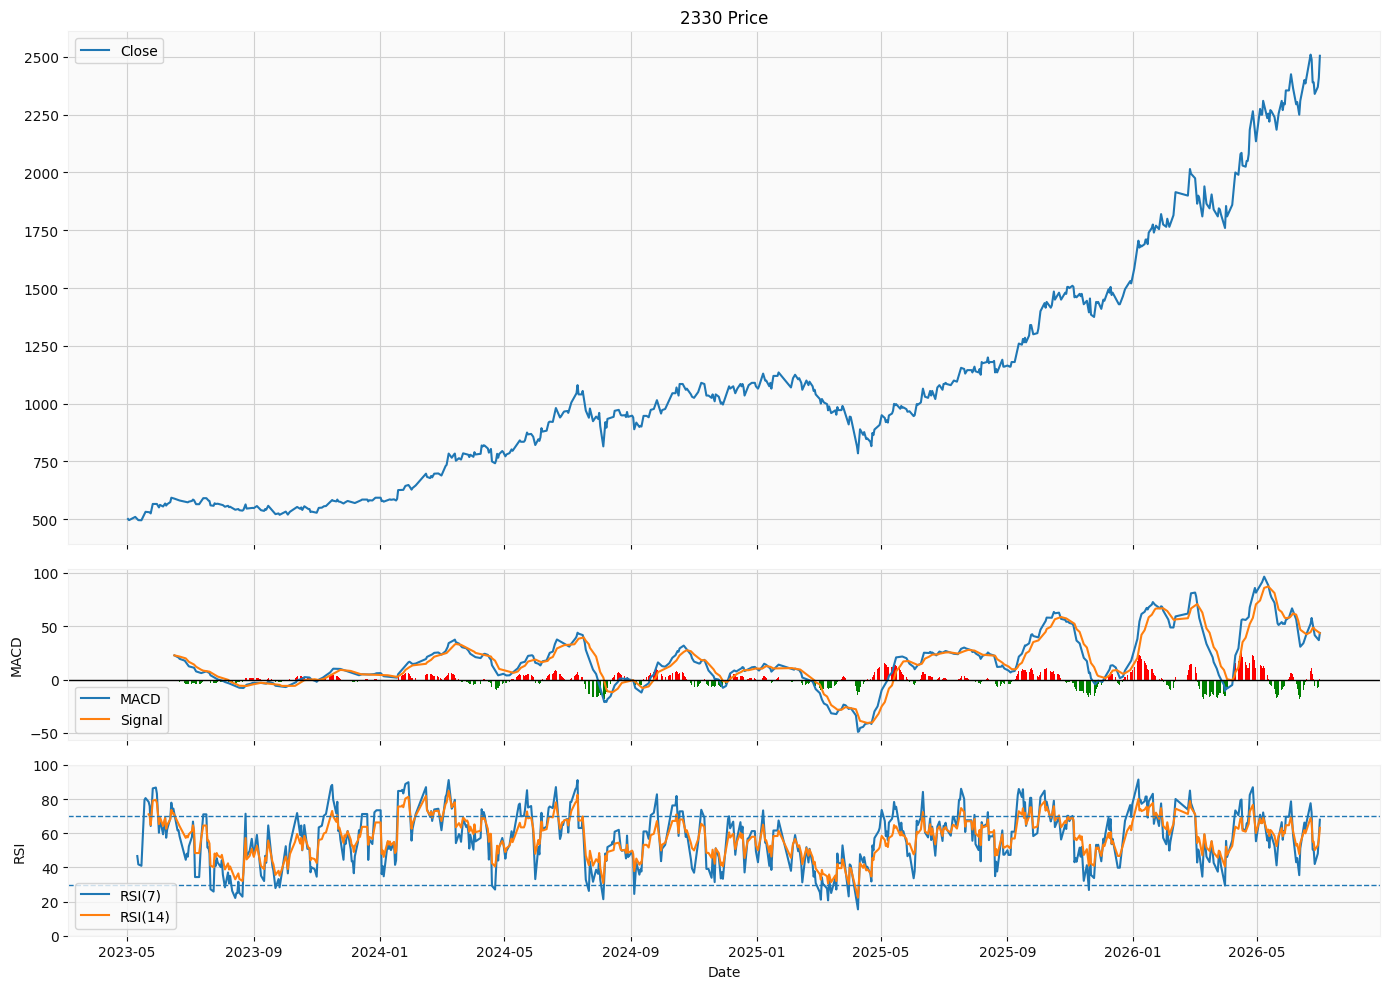

In [119]:
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1, 1]})

# 股價
ax1.plot(df["date"], df["close"], label="Close")
ax1.set_title("2330 Price")
ax1.legend()
ax1.grid(True)

# MACD
ax2.plot(df["date"], df["MACD"], label="MACD")
ax2.plot(df["date"], df["MACD_Signal"], label="Signal")

colors = ["red" if x >= 0 else "green" for x in df["MACD_Hist"]]
ax2.bar(df["date"], df["MACD_Hist"], color=colors, width=1)

ax2.axhline(0, color="black", linewidth=1)

ax2.set_ylabel("MACD")
ax2.legend()
ax2.grid(True)

# RSI
ax3.plot(df["date"], df["RSI_7"], label="RSI(7)")
ax3.plot(df["date"], df["RSI_14"], label="RSI(14)")
ax3.axhline(70, linestyle="--", linewidth=1)
ax3.axhline(30, linestyle="--", linewidth=1)
ax3.set_ylim(0, 100)

ax3.set_ylabel("RSI")
ax3.set_xlabel("Date")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

# 輸出計算好的指標，接著就要設定交易策略做回測，並計算報酬

In [120]:
XXX
# df.info()
df.to_csv("2330_Cal.csv", index=False)

NameError: name 'XXX' is not defined

參考資料

https://www.oanda.com/bvi-ft/lab-education/technical_analysis/use_kd/

https://www.oanda.com/bvi-ft/lab-education/technical_analysis/what_is_rsi/

https://havocfuture.tw/blog/python-indicators-talib

https://zhuanlan.zhihu.com/p/342075180
